## Ensemble Engineer


Se implementará técnicas de VotingClassfier (hard y soft voting) usando los modelos que mejor se han desempeñado en el baseline:

* Random Forest

* Decisition Tree

* XGBoost



In [1]:
import joblib
import pandas as pd

from sklearn.ensemble import VotingClassifier
from sklearn.model_selection import cross_validate
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score
)

In [2]:
# =========================================================
# Cargar datasets
# =========================================================

X_train = pd.read_csv("../data/processed/X_train_bal.csv")
y_train = pd.read_csv("../data/processed/y_train_bal.csv").squeeze()

X_test = pd.read_csv("../data/processed/X_test.csv")
y_test = pd.read_csv("../data/processed/y_test.csv").squeeze()

In [3]:
# =========================================================
# Cargar modelos entrenados
# =========================================================

best_xgb = joblib.load("../models/tuned_xgb.pkl")
best_rf  = joblib.load("../models/tuned_rf.pkl")

In [4]:
# =========================================================
# Configuración CV y métricas
# =========================================================

scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1'
}

cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

In [5]:
# =========================================================
# HARD VOTING
# =========================================================

hard_voting = VotingClassifier(
    estimators=[
        ('rf', best_rf),
        ('xgb', best_xgb)
    ],
    voting='hard'
)

# Cross-validation
hard_scores = cross_validate(
    hard_voting,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
    return_train_score=False
)

print("=== HARD VOTING CV RESULTS ===")
for metric in scoring.keys():
    print(
        f"{metric}: "
        f"{hard_scores[f'test_{metric}'].mean():.4f}"
    )

# Entrenamiento final
hard_voting.fit(X_train, y_train)

# Predicción
y_pred_hard = hard_voting.predict(X_test)

print("\n=== HARD VOTING TEST REPORT ===")
print(classification_report(y_test, y_pred_hard))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_hard))

=== HARD VOTING CV RESULTS ===
accuracy: 0.8731
precision: 0.9135
recall: 0.8241
f1: 0.8665

=== HARD VOTING TEST REPORT ===
              precision    recall  f1-score   support

           0       0.87      0.93      0.90     15002
           1       0.86      0.76      0.81      8839

    accuracy                           0.86     23841
   macro avg       0.86      0.84      0.85     23841
weighted avg       0.86      0.86      0.86     23841


Confusion Matrix:
[[13887  1115]
 [ 2112  6727]]


In [7]:
# =========================================================
# SOFT VOTING
# =========================================================

soft_voting = VotingClassifier(
    estimators=[
        ('rf', best_rf),
        ('xgb', best_xgb)
    ],
    voting='soft',

    # Más peso a RF y XGB
    weights=[3, 3]
)

# Cross-validation
soft_scores = cross_validate(
    soft_voting,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
    return_train_score=False
)

print("\n==============================")
print("SOFT VOTING - CV RESULTS")
print("==============================")

for metric in scoring.keys():
    print(
        f"{metric}: "
        f"{soft_scores[f'test_{metric}'].mean():.4f}"
    )

# Entrenamiento final
soft_voting.fit(X_train, y_train)

# Predicciones
y_pred_soft = soft_voting.predict(X_test)

# Probabilidades
y_prob_soft = soft_voting.predict_proba(X_test)[:, 1]

print("\n==============================")
print("SOFT VOTING - TEST REPORT")
print("==============================")

print(classification_report(y_test, y_pred_soft))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_soft))

# ROC-AUC
auc_soft = roc_auc_score(y_test, y_prob_soft)

print(f"\nSoft Voting ROC-AUC: {auc_soft:.4f}")


SOFT VOTING - CV RESULTS
accuracy: 0.8806
precision: 0.8927
recall: 0.8652
f1: 0.8787

SOFT VOTING - TEST REPORT
              precision    recall  f1-score   support

           0       0.89      0.90      0.90     15002
           1       0.83      0.80      0.82      8839

    accuracy                           0.87     23841
   macro avg       0.86      0.85      0.86     23841
weighted avg       0.87      0.87      0.87     23841


Confusion Matrix:
[[13552  1450]
 [ 1726  7113]]

Soft Voting ROC-AUC: 0.9353


In [8]:
# =========================================================
# Guardar modelos ensemble
# =========================================================

joblib.dump(
    hard_voting,
    "../models/ensemble_hv.pkl"
)

joblib.dump(
    soft_voting,
    "../models/ensemble_sv.pkl"
)

print("\nVoting classifiers guardados correctamente.")


Voting classifiers guardados correctamente.


## Construcción de un Stacking Classifier

Para la construcción del stacking classifier trabajaremos con los siguientes modelos:

* Random Forest

* Decisition Tree

* XGBoost

In [9]:
import pandas as pd
import joblib

from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
    roc_auc_score
)

In [2]:
# =========================================================
# LOAD DATA
# =========================================================

X_train = pd.read_csv("../data/processed/X_train_bal.csv")
y_train = pd.read_csv("../data/processed/y_train_bal.csv").squeeze()

X_test = pd.read_csv("../data/processed/X_test.csv")
y_test = pd.read_csv("../data/processed/y_test.csv").squeeze()

In [3]:
# =========================================================
# LOAD BEST BASE MODELS
# =========================================================

best_xgb = joblib.load("../models/tuned_xgb.pkl")
best_rf  = joblib.load("../models/tuned_rf.pkl")

In [10]:
# =========================================================
# META-LEARNER
# =========================================================

meta_learner = LogisticRegression(
    max_iter=1000,
    random_state=42
)

In [11]:

# =========================================================
# STACKING CLASSIFIER
# =========================================================

stack_model = StackingClassifier(
    estimators=[
        ("xgb", best_xgb),
        ("rf", best_rf)
    ],
    
    final_estimator=meta_learner,

    # Usa probabilidades como input del meta-modelo
    stack_method="predict_proba",

    # Cross-validation interna
    cv=5,

    # Usa predicciones originales + probabilidades
    passthrough=False,

    n_jobs=-1
)

In [12]:
# =========================================================
# TRAIN
# =========================================================

print("Training Stacking Classifier...")

stack_model.fit(X_train, y_train)

print("Training completed.")

Training Stacking Classifier...
Training completed.


In [13]:
# =========================================================
# PREDICTIONS
# =========================================================

y_pred = stack_model.predict(X_test)
y_prob = stack_model.predict_proba(X_test)[:, 1]

In [14]:
# =========================================================
# EVALUATION
# =========================================================

print("\n==============================")
print("STACKING CLASSIFIER RESULTS")
print("==============================\n")

print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred):.4f}")
print(f"ROC AUC  : {roc_auc_score(y_test, y_prob):.4f}")

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))


STACKING CLASSIFIER RESULTS

Accuracy : 0.8662
F1 Score : 0.8188
ROC AUC  : 0.9351

Classification Report:

              precision    recall  f1-score   support

           0       0.89      0.90      0.89     15002
           1       0.82      0.82      0.82      8839

    accuracy                           0.87     23841
   macro avg       0.86      0.86      0.86     23841
weighted avg       0.87      0.87      0.87     23841


Confusion Matrix:

[[13448  1554]
 [ 1635  7204]]


In [15]:
# =========================================================
# SAVE MODEL
# =========================================================

joblib.dump(
    stack_model,
    "../models/ensemble_stack.pkl"
)

print("\nStacking model saved successfully.")


Stacking model saved successfully.


## Evaluación todos los ensambles con cross-validation y comparación con los baselines tuneados.

### 1. Cargar datos y modelos

In [16]:
import sys
import os

sys.path.append(os.path.abspath(".."))

import pandas as pd
import os
import joblib

# ========================
# 1. Cargar dataset
# ========================

import pandas as pd

df = pd.read_csv('../data/interim/hotel_bookings_fe.csv')

print("Shape:", df.shape)

# ========================
# 2. Cargar modelos ensemble
# ========================

models_path = "../models"

models = {}

for file in os.listdir(models_path):
    if file.startswith("ensemble_") and file.endswith(".pkl"):
        name = file.replace("ensemble_", "").replace(".pkl", "")
        models[name] = joblib.load(os.path.join(models_path, file))

# ========================
# 3. Cargar modelos baseline tuneados
# ========================

models["tuned_xgb"] = joblib.load("../models/tuned_xgb.pkl")
models["tuned_rf"]  = joblib.load("../models/tuned_rf.pkl")

# ========================
# 4. Verificar modelos cargados
# ========================

print("Modelos cargados:")
print(models.keys())

Shape: (119204, 65)
Modelos cargados:
dict_keys(['hv', 'stack', 'sv', 'tuned_xgb', 'tuned_rf'])


In [17]:
# ========================
# 2. Distribución del target
# ========================

target_dist = df['is_canceled'].value_counts(normalize=True)

print(target_dist)

is_canceled
0    0.629257
1    0.370743
Name: proportion, dtype: float64


In [18]:
# ========================
# 3. Separar variables
# ========================

X = df.drop('is_canceled', axis=1)
y = df['is_canceled']

In [19]:
# ========================
# 4. Train/Test Split
# ========================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,        
    random_state=42
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (95363, 64)
Test: (23841, 64)


# 2. Cross-validation + Test evaluation

In [21]:
# ========================
# 5. Cross-validation usando la data train original sin balancear
# ========================

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.base import clone
import time

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc'
}

results_list = []

print("\n Iniciando evaluación de modelos...\n")

for name, model in models.items():

    print(f"\nEvaluando: {name}")

    # ------------------------
    # Scoring dinámico
    # ------------------------
    current_scoring = {
        'accuracy': 'accuracy',
        'precision': 'precision',
        'recall': 'recall',
        'f1': 'f1'
    }

    # Solo agregar AUC si el modelo soporta probabilidades
    if hasattr(model, "predict_proba") or hasattr(model, "decision_function"):
        current_scoring['roc_auc'] = 'roc_auc'

    # ------------------------
    # Cross-validation
    # ------------------------
    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=current_scoring,
        n_jobs=-1
    )

    # ------------------------
    # Entrenamiento
    # ------------------------
    model_clone = clone(model)
    model_clone.fit(X_train, y_train)

    y_pred = model_clone.predict(X_test)

    # ------------------------
    # AUC test
    # ------------------------
    if hasattr(model_clone, "predict_proba"):
        y_proba = model_clone.predict_proba(X_test)[:, 1]
        auc_test = roc_auc_score(y_test, y_proba)

    elif hasattr(model_clone, "decision_function"):
        y_proba = model_clone.decision_function(X_test)
        auc_test = roc_auc_score(y_test, y_proba)

    else:
        auc_test = None

    # ------------------------
    # Resultados
    # ------------------------
    results_list.append({
        'Modelo': name,

        'CV_Accuracy': scores['test_accuracy'].mean(),
        'CV_Precision': scores['test_precision'].mean(),
        'CV_Recall': scores['test_recall'].mean(),
        'CV_F1': scores['test_f1'].mean(),

        'CV_AUC': scores['test_roc_auc'].mean()
                    if 'test_roc_auc' in scores else None,

        'Test_Accuracy': accuracy_score(y_test, y_pred),
        'Test_Precision': precision_score(y_test, y_pred, zero_division=0),
        'Test_Recall': recall_score(y_test, y_pred, zero_division=0),
        'Test_F1': f1_score(y_test, y_pred, zero_division=0),
        'Test_AUC': auc_test,

        'Train_Time': scores['fit_time'].mean()
    })

print("\n Consolidando resultados...")


 Iniciando evaluación de modelos...


Evaluando: hv

Evaluando: stack

Evaluando: sv

Evaluando: tuned_xgb

Evaluando: tuned_rf

 Consolidando resultados...


In [22]:
# ========================
# 6. DataFrame final
# ========================
df_results = pd.DataFrame(results_list)

# ------------------------
# Overfitting check
# ------------------------
df_results['F1_gap'] = df_results['CV_F1'] - df_results['Test_F1']
df_results['Recall_gap'] = df_results['CV_Recall'] - df_results['Test_Recall']

# ------------------------
# Orden final (F1)
# ------------------------
df_results = df_results[[
    'Modelo',
    'CV_F1', 'Test_F1',
    'CV_Recall', 'Test_Recall', 'CV_Accuracy',
    'CV_AUC', 'Test_AUC',
    'Train_Time',
    'F1_gap', 'Recall_gap'
]].sort_values('CV_Recall', ascending=False)

print(" Evaluación completada\n")

df_results

 Evaluación completada



,Modelo,CV_F1,Test_F1,CV_Recall,Test_Recall,CV_Accuracy,CV_AUC,Test_AUC,Train_Time,F1_gap,Recall_gap
3,tuned_xgb,0.804143,0.812544,0.766257,0.775314,0.861624,0.927303,0.935699,1.965272,-0.008402,-0.009057
1,stack,0.805382,0.814951,0.761901,0.774522,0.863490,0.929251,0.936402,87.535519,-0.009569,-0.012621
2,sv,0.802555,0.812772,0.749512,0.760267,0.863280,0.929873,0.937028,19.162004,-0.010217,-0.010755
4,tuned_rf,0.785022,0.793306,0.713421,0.724064,0.855143,0.924281,0.930729,17.080857,-0.008285,-0.010643
0,hv,0.780595,0.792933,0.692292,0.708338,0.855730,NaN,NaN,19.049359,-0.012338,-0.016046


In [23]:
df_results['Rank'] = df_results['CV_Recall'].rank(ascending=False)
df_results.sort_values('Rank')

,Modelo,CV_F1,Test_F1,CV_Recall,Test_Recall,CV_Accuracy,CV_AUC,Test_AUC,Train_Time,F1_gap,Recall_gap,Rank
3,tuned_xgb,0.804143,0.812544,0.766257,0.775314,0.861624,0.927303,0.935699,1.965272,-0.008402,-0.009057,1.0
1,stack,0.805382,0.814951,0.761901,0.774522,0.863490,0.929251,0.936402,87.535519,-0.009569,-0.012621,2.0
2,sv,0.802555,0.812772,0.749512,0.760267,0.863280,0.929873,0.937028,19.162004,-0.010217,-0.010755,3.0
4,tuned_rf,0.785022,0.793306,0.713421,0.724064,0.855143,0.924281,0.930729,17.080857,-0.008285,-0.010643,4.0
0,hv,0.780595,0.792933,0.692292,0.708338,0.855730,NaN,NaN,19.049359,-0.012338,-0.016046,5.0


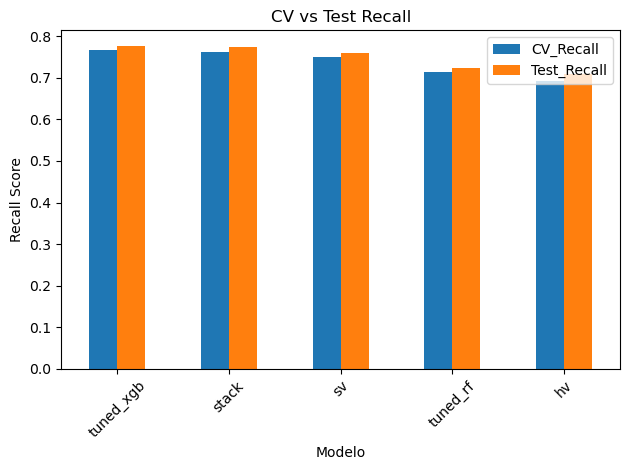

In [24]:
import matplotlib.pyplot as plt

df_plot = df_results.set_index('Modelo')[['CV_Recall', 'Test_Recall']]

df_plot.plot(kind='bar')
plt.title("CV vs Test Recall")
plt.ylabel("Recall Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

A partir de los resultados, se observa que las combinaciones basadas en métodos de ensamblaje (ensemble learning) logran un desempeño competitivo respecto a los modelos individuales tuneados, especialmente en términos de F1-score y capacidad de generalización.

**Modelos con mejor desempeño**

El modelo con mejor rendimiento global fue XGBoost tuneado (tuned_xgb), alcanzando:

* Test F1 = 0.8125
* Test Recall = 0.7753
* Test AUC = 0.9357

Esto sugiere que el modelo logra un buen equilibrio entre precisión y sensibilidad, además de una alta capacidad de discriminación entre clases. El bajo valor de F1_gap y Recall_gap indica además una buena generalización y ausencia significativa de overfitting.

**Combinaciones ensemble que funcionan mejor**

1. Stacking (stack)

El modelo stacking obtuvo resultados muy cercanos al mejor modelo individual:

* Test F1 = 0.8150 (el más alto)
* Test Recall = 0.7745
* Test AUC = 0.9364

El buen desempeño del stacking se debe a que combina las fortalezas de varios modelos base mediante un meta-modelo que aprende cuándo confiar más en cada estimador. Esta estrategia suele funcionar bien cuando los modelos base tienen errores parcialmente diferentes.

En este caso, el stacking probablemente logró:

* aprovechar la capacidad predictiva de XGBoost,
* complementar patrones capturados por Random Forest,
* y reducir errores individuales mediante agregación.

Sin embargo, el tiempo de entrenamiento fue considerablemente mayor (87.5 s), lo que evidencia el costo computacional adicional del ensamblaje multicapa.

2. Soft Voting (sv)

El modelo de soft voting también mostró resultados sólidos:

* Test F1 = 0.8128
* Test Recall = 0.7603
* Test AUC = 0.9370 (el más alto)

Esta combinación funciona bien porque el soft voting promedia probabilidades en lugar de votos discretos. Esto permite:

aprovechar mejor la confianza probabilística de cada clasificador,
reducir la varianza,
y mejorar la estabilidad del modelo final.

El alto AUC obtenido sugiere que el ensamblaje mejora la capacidad de separación entre clases, incluso manteniendo un tiempo de entrenamiento moderado.

**Combinaciones menos efectivas**
Hard Voting (hv)

El modelo de hard voting fue el de menor desempeño:

* Test F1 = 0.7929
* Test Recall = 0.7083

Este comportamiento era esperable debido a que:

el hard voting toma decisiones binarias por mayoría,
ignora las probabilidades y niveles de confianza,
y puede perder información útil en problemas desbalanceados.

Además, no pudo calcularse ROC AUC porque el clasificador no implementa predict_proba(), limitando su capacidad de evaluación probabilística.

## Comparación general

Los resultados muestran que:

* XGBoost sigue siendo el modelo individual más robusto.
* El stacking logra el mejor F1-score gracias a la combinación inteligente de modelos.
* El soft voting ofrece el mejor balance entre desempeño, estabilidad y costo computacional.
* El hard voting resulta menos adecuado para este problema debido a la pérdida de información probabilística.

En conjunto, esto evidencia que las técnicas ensemble sí aportan mejoras, especialmente cuando se utilizan métodos probabilísticos como soft voting o arquitecturas más sofisticadas como stacking.